In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [4]:
df = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_gene_protein.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df = df.loc[:, ~df.columns.str.contains('Norm')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df = df.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T
df1 = df.drop(['ATXN7', 'ATXN7', 'ABCF2', 'ABCF2', 'GGT1', 'GGT1', 'PINX1', 'PINX1',
       'POLR2J3', 'POLR2J3'],axis = 1) #columnas duplicadas
df2 = df[['ATXN7', 'ABCF2', 'GGT1', 'PINX1',  'POLR2J3']]
##Cambiamos los nombres de las columnas duplicadas
cols = ['ATXN7', 'ATXN7', 'ABCF2', 'ABCF2', 'GGT1', 'GGT1', 'PINX1', 'PINX1','POLR2J3', 'POLR2J3']
col_counts = defaultdict(int)
new_cols = []

for col in cols:
    if col_counts[col] == 0:
        new_cols.append(f"{col}_a")
    else:
        new_cols.append(f"{col}_b")
    col_counts[col] += 1
df2.columns = new_cols
df_raw = pd.concat([df1,df2], axis=1)

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

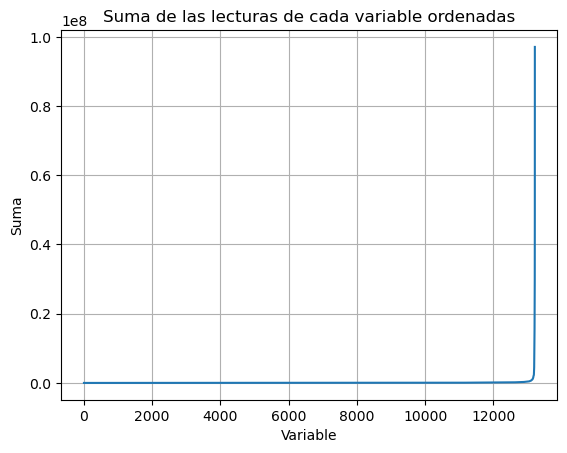

In [ ]:

plt.plot(df_raw.sum().sort_values().to_list())
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

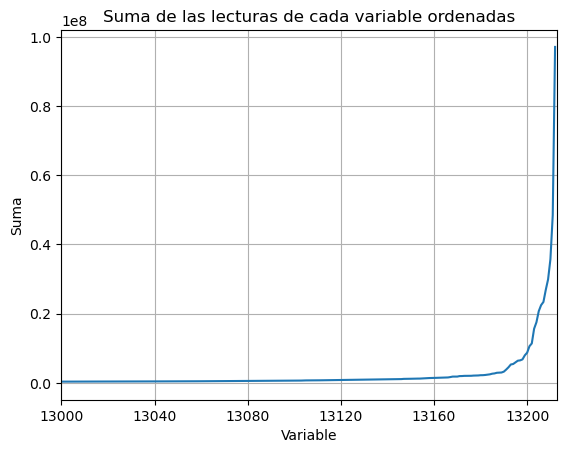

In [ ]:
plt.xticks(np.arange(13000, 13213 , 40))
plt.plot(df_raw.sum().sort_values().to_list())
plt.xlim(13000, 13213)
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

In [ ]:
x_objetivo = 13000

suma_lecturas = df_raw.sum().sort_values()
suma_lecturas_list = suma_lecturas.to_list()
indice_mas_cercano = np.abs(suma_lecturas.reset_index(drop = True).index - x_objetivo).argmin()
valor_y_MIespondiente = suma_lecturas.iloc[indice_mas_cercano]

print(f"El valor de y correspondiente a x={x_objetivo} es: {valor_y_correspondiente}")

El valor de y correspondiente a x=13000 es: 373526


In [ ]:
suma_min = valor_y_correspondiente
filtered = df_raw.sum().sort_values()
cols_interes = filtered[filtered>suma_min].index.to_list()
df_raw_lecAltas1 = df_raw[cols_interes]
len(df_raw_lecAltas1.columns)

212

### MAgnitud mínima

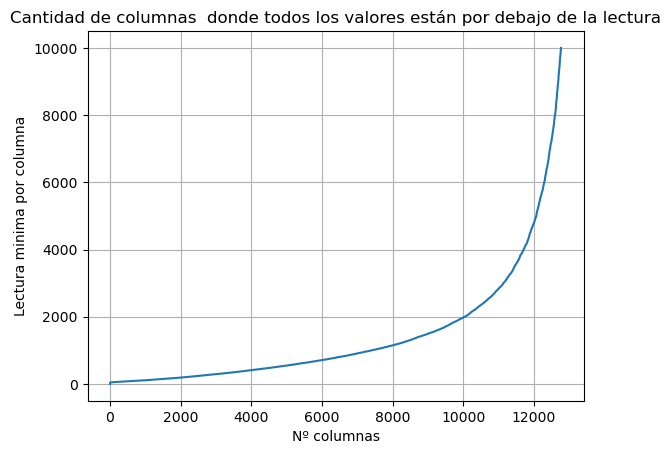

In [ ]:
lista_mediaCercACero = []
lecturas_mins = range(0,10000)
for lectMin in lecturas_mins:
    #for frec in np.arange(0,1,0.1):
    mediaCercACero = (df_raw < lectMin).sum() #vemos cuántos valores de cada columna están por debajo de ese umbral
    mediaCercACero = mediaCercACero[mediaCercACero == len(df_raw)] #Filtramos las columnas en donde todos los valores están por debajo de ese umbral
    lista_mediaCercACero.append(len(mediaCercACero))
#plt.xticks(np.arange(0,20,1))
plt.plot(lista_mediaCercACero, lecturas_mins)
plt.xlabel('Nº columnas')
plt.ylabel('Lectura minima por columna')
plt.title('Cantidad de columnas  donde todos los valores están por debajo de la lectura') 
plt.grid(True)
plt.show()

In [ ]:
ncol = 12000
indice_mas_cercano = np.abs(np.array(lista_mediaCercACero) - ncol).argmin()
lectura_correspondiente = lecturas_mins[indice_mas_cercano] 
print(f"El valor de lectura correspondiente a x={ncol} es aproximadamente: {lectura_correspondiente}")

El valor de lectura correspondiente a x=12000 es aproximadamente: 4773


In [ ]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

1213

In [ ]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

1213

In [ ]:
colsLectAlta = list(set(df_raw_lecAltas1.columns.to_list() + df_raw_lecAltas2.columns.to_list()))
len(colsLectAlta)
print(len(df_raw.columns),'->',len(colsLectAlta))

13213 -> 1213


### Varianzas bajas

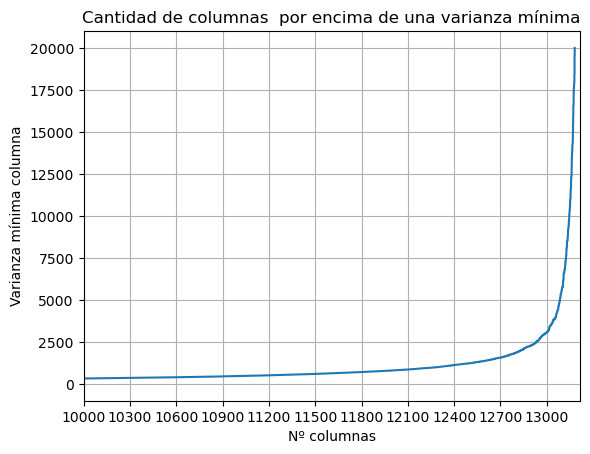

In [ ]:
lista_vars = []
vars_mins = range(0,20000)
df_vars = df_raw.std()
for varMin in vars_mins:
    nVarsStd = len(df_vars[df_vars<varMin])
    lista_vars.append(nVarsStd)

plt.xticks(np.arange(10000, 13213,300))
plt.plot(lista_vars, vars_mins)
plt.xlim(10000, 13213)
plt.xlabel('Nº columnas')
plt.ylabel('Varianza mínima columna')
plt.title('Cantidad de columnas  por encima de una varianza mínima') 
plt.grid(True)
plt.show()

In [ ]:
lista_vars_array = np.array(lista_vars)
vars_mins_array = np.array(vars_mins)
x_objetivo = 12800
indice_mas_cercano = np.abs(lista_vars_array - x_objetivo).argmin()
varianza_minima_correspondiente = vars_mins_array[indice_mas_cercano]

print(f"La varianza mínima correspondiente a x={x_objetivo} columnas es: {varianza_minima_correspondiente}")

La varianza mínima correspondiente a x=12800 columnas es: 1854


In [ ]:
colsVarAlta = df_vars[df_vars>varianza_minima_correspondiente].index.to_list()
print(len(df_raw.columns),'->',len(colsVarAlta))


13213 -> 413


In [ ]:
colsSeleccion = list(set(colsLectAlta + colsVarAlta))
df_raw_new = df_raw[colsSeleccion]
len(colsSeleccion)

1213

### Renormalizar

In [ ]:
df_raw_new.to_csv('df_raw_Proteines_Normalizar.csv',index = False)

In [5]:
df_norm_TMM = pd.read_csv('cpm_tmmProteines.csv',index_col = 0)

In [6]:
df_norm_TMM.index = df_raw.index

### Tests

In [8]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [9]:
df_norm_seleccion = df_norm_TMM
df1_ct = df_norm_seleccion.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

print(len(variables),'→',len(variablesIncluir))

1213 → 78


### Correlaciones

In [10]:
df1 = df_norm_TMM[variablesIncluir]

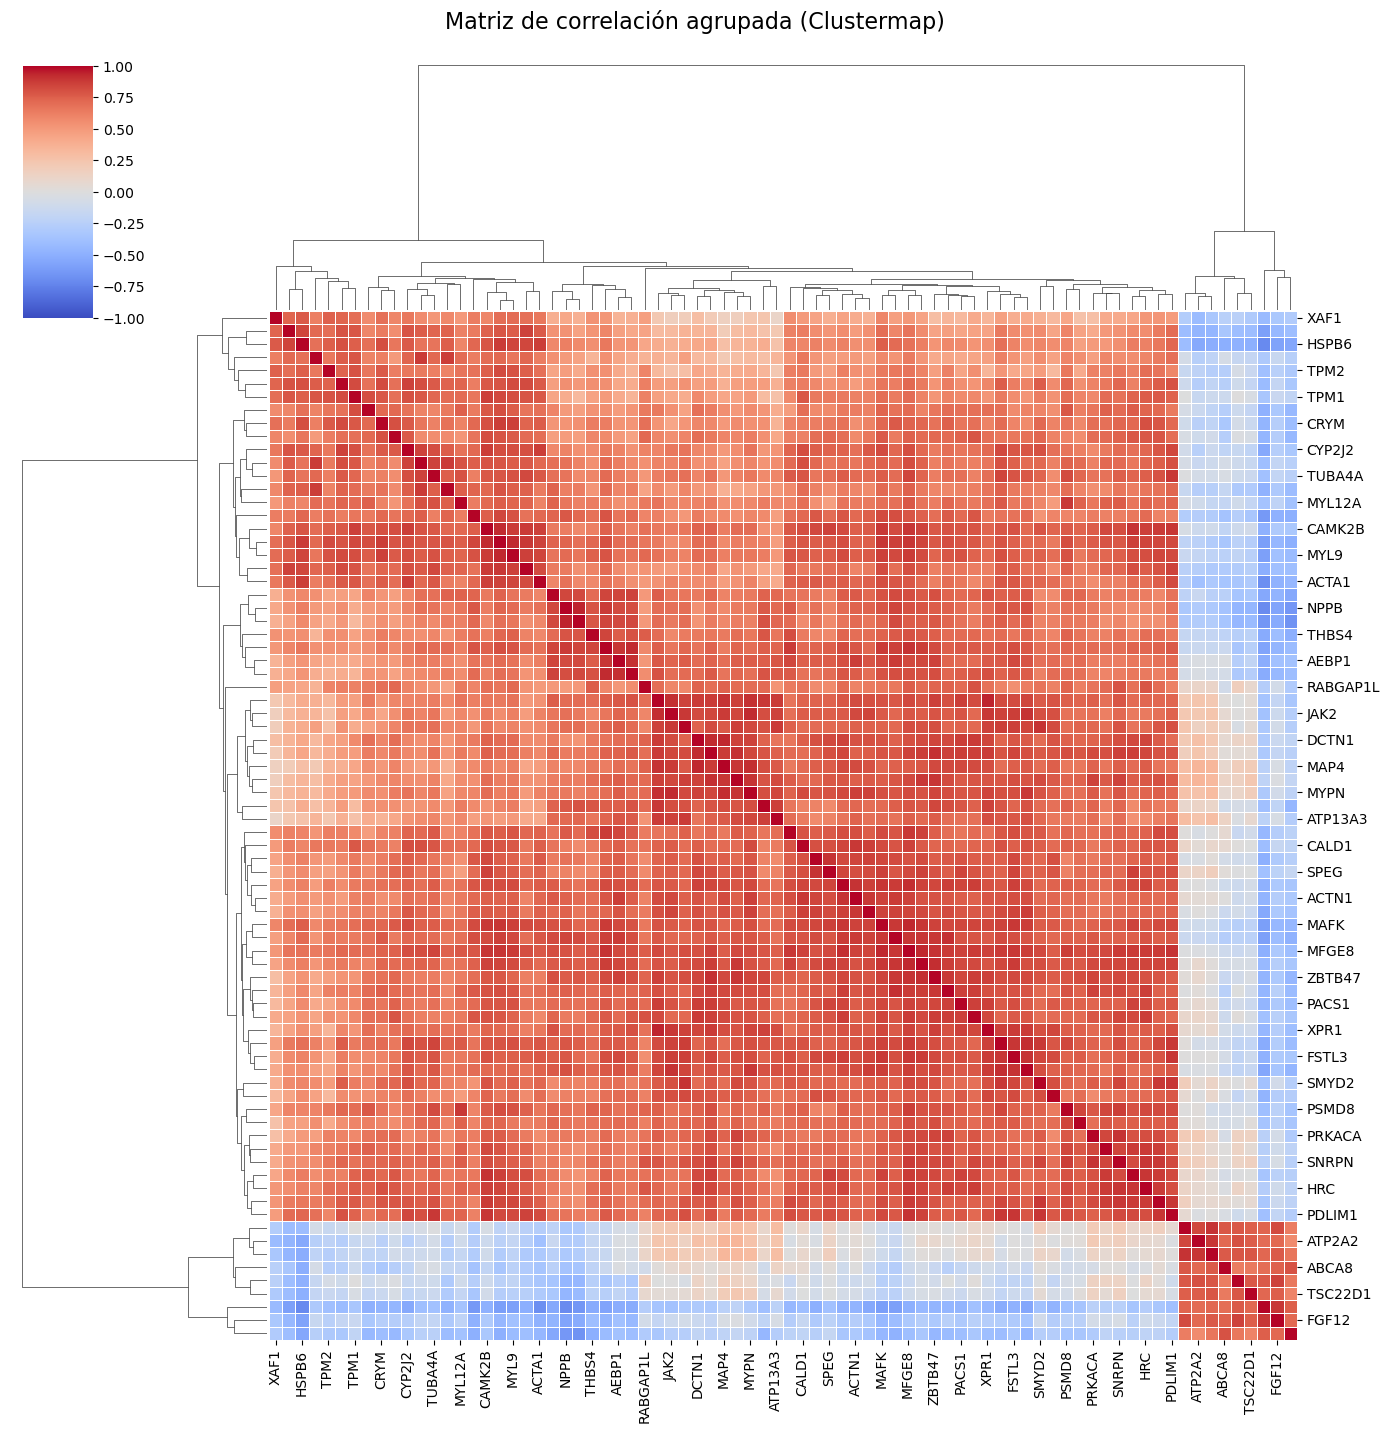

In [ ]:
import seaborn as sns

corr = df1.corr(method='spearman')
cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7})
cluster.fig.suptitle('Matriz de correlación agrupada (Clustermap)', y=1.02, fontsize=16)
cluster.fig.savefig("graphics/clustermap_correlacionProteinas.png", bbox_inches='tight', dpi=300)
plt.show()

Correlacion + infoMutua

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was 

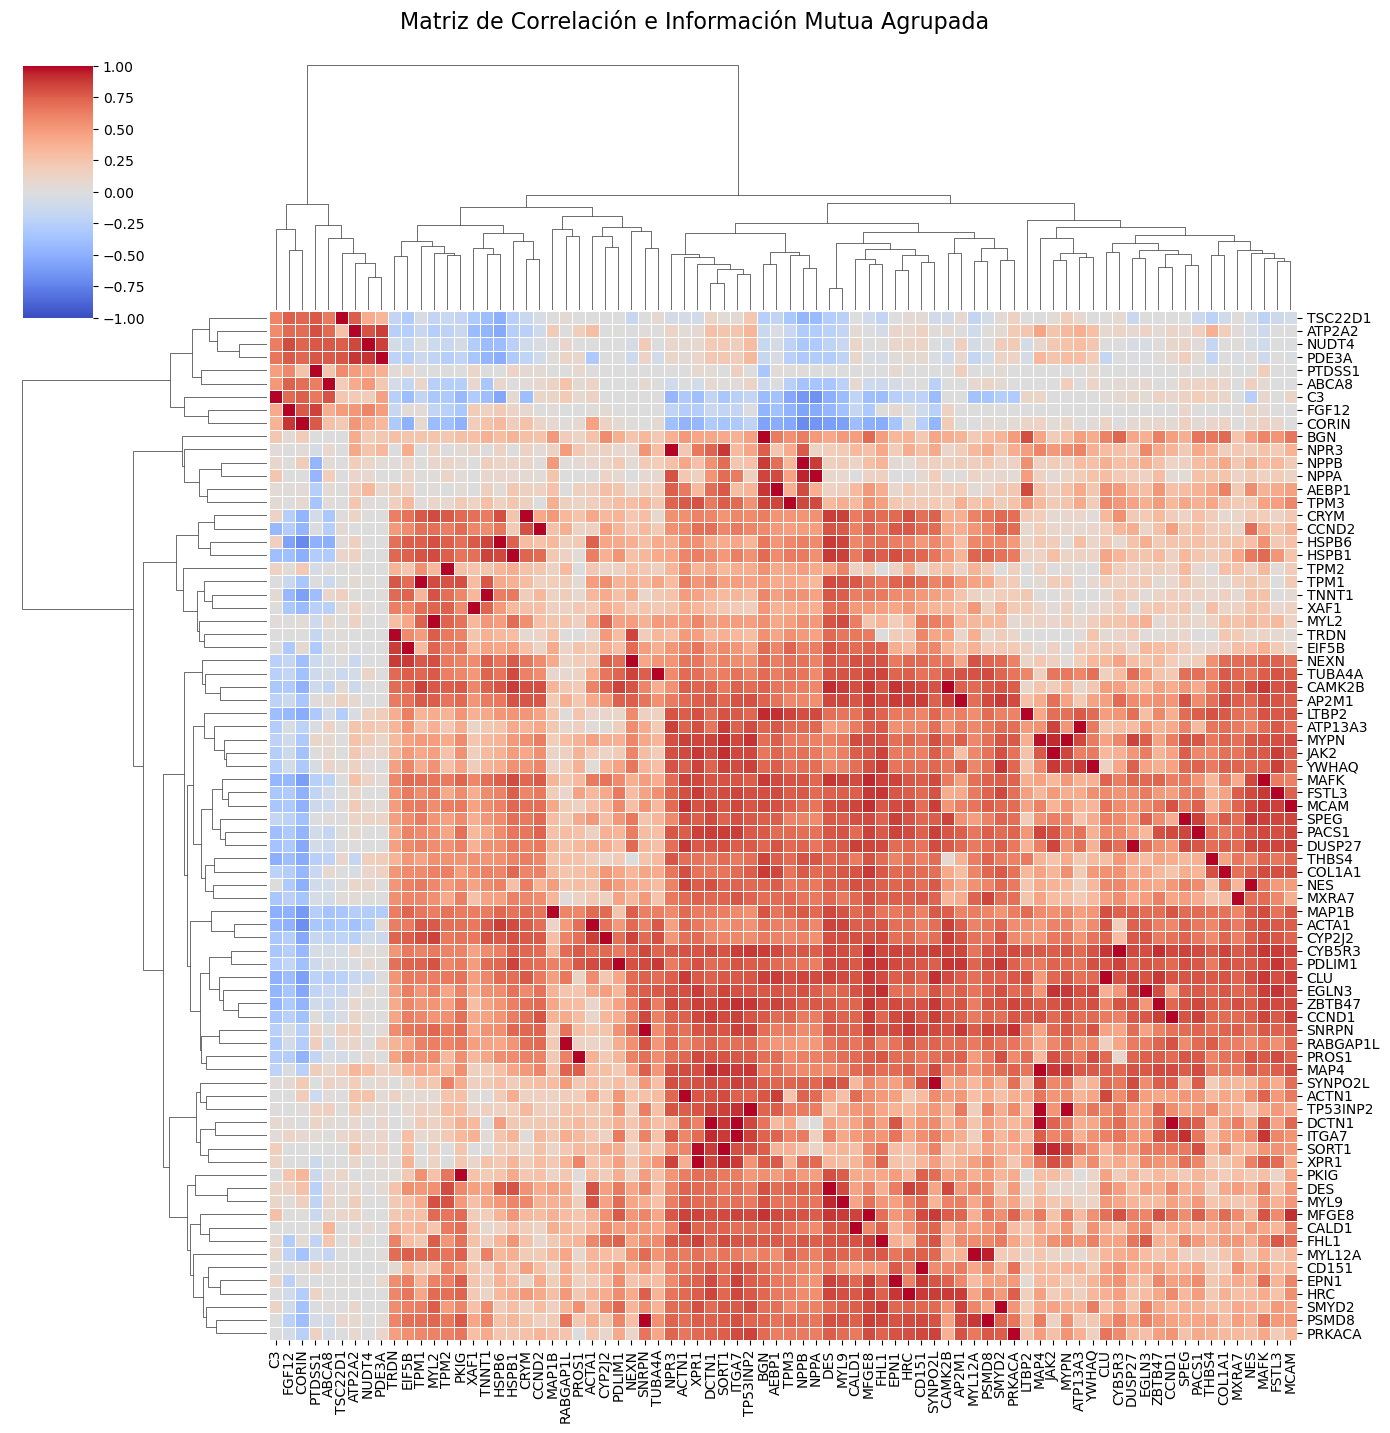

In [ ]:
from sklearn.feature_selection import mutual_info_regression

corr = df1.corr(method='spearman')  
mi_matrix = np.zeros_like(corr) 

for i in range(len(df1.columns)):
    for j in range(i+1, len(df1.columns)):
        mi = mutual_info_regression(df1[[df1.columns[i]]], df1[[df1.columns[j]]])[0]
        mi_matrix[i, j] = mi
        mi_matrix[j, i] = mi
combined_matrix = np.copy(corr)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # Máscara para el lado superior de la diagonal
combined_matrix[mask] = mi_matrix[mask]

cluster = sns.clustermap(combined_matrix,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7},
                         xticklabels=df1.columns,
                         yticklabels=df1.columns) 
cluster.fig.suptitle('Matriz de Correlación e Información Mutua Agrupada', y=1.02, fontsize=16)
cluster.fig.savefig("../graphics/clustermap_correlacion_informacion_mutuaProteinas.png", bbox_inches='tight', dpi=300)

plt.show()

### Clustering

In [12]:
from sklearn.metrics import silhouette_score

#### Kmeans

In [13]:
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings
warnings.filterwarnings('ignore')

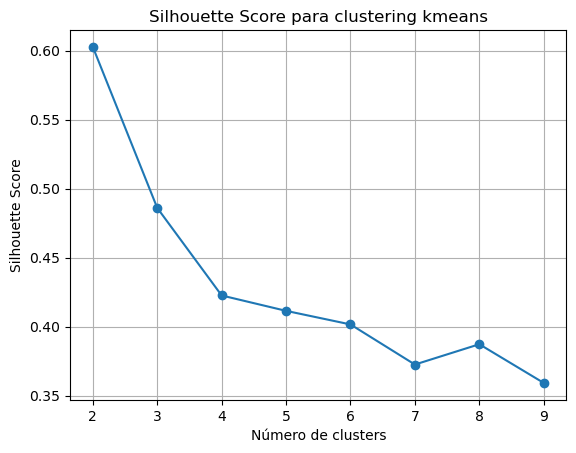

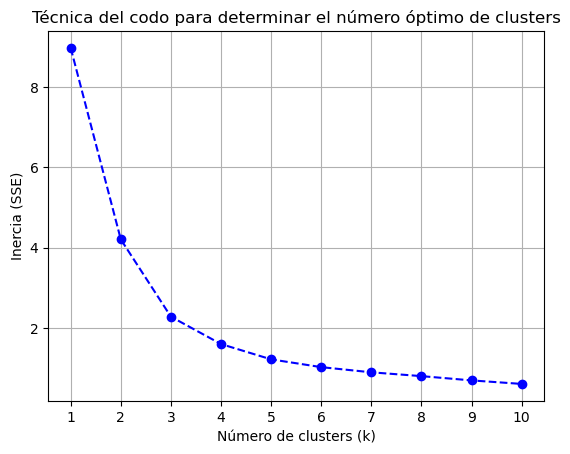

In [ ]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)


sil_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, init ='random')
    labels = kmeans.fit_predict(X_mds)
    sil = silhouette_score(X_mds, labels)
    sil_scores.append(sil)

plt.plot(range(2, 10), sil_scores, marker='o')
plt.title('Silhouette Score para clustering kmeans')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_mds)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o', color='b', linestyle='--')
plt.title('Técnica del codo para determinar el número óptimo de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (SSE)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


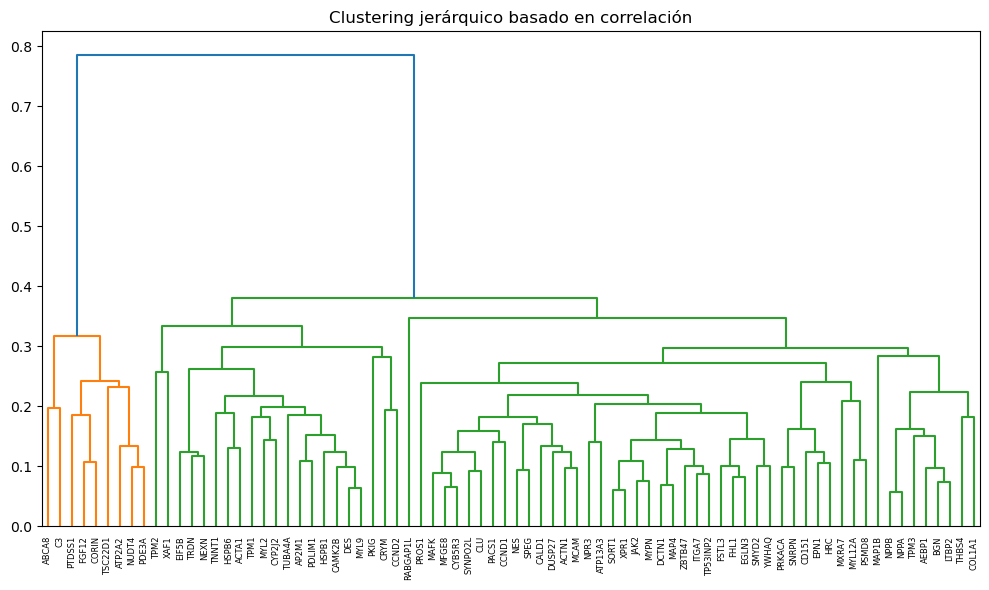

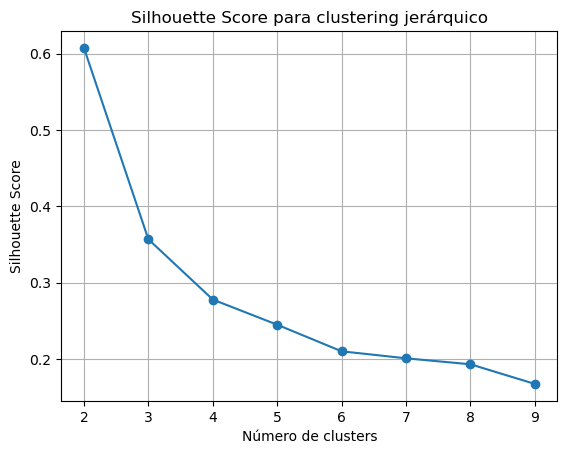

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram,fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score


corr = df1.corr(method='spearman') 
dist = 1 - corr.abs()


dist_vec = squareform(dist.values)

Z = linkage(dist_vec, method='average') 


plt.figure(figsize=(10, 6))
dendrogram(Z, labels=corr.columns, leaf_rotation=90)
plt.title('Clustering jerárquico basado en correlación')
plt.tight_layout()
plt.show()

Z = linkage(dist_vec, method='average') 
sil_scores = []
for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    sil = silhouette_score(dist, labels, metric='precomputed')
    sil_scores.append(sil)

plt.plot(range(2, 10), sil_scores, marker='o')
plt.title('Silhouette Score para clustering jerárquico')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

En base a la correlación mínima en cada cluster y a la correlación máxima entre clusters

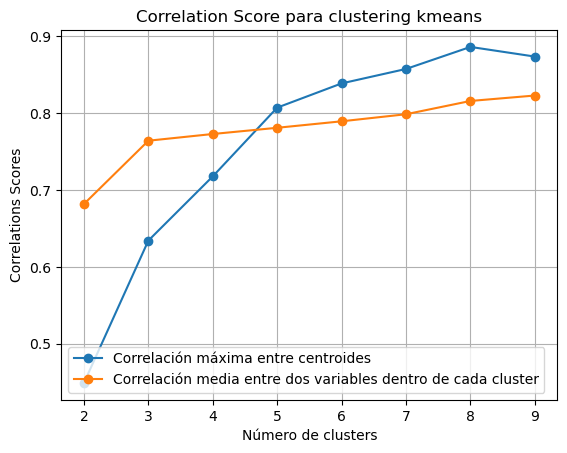

In [ ]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)

mincorr_scores_mean = []
meancorr_scores_mean = []
centroidesMaxcorr_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_mds)
    cluster_df = pd.DataFrame({'variable': corr.columns, 'cluster': labels})
    closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_mds) #sacar centroide
    variables_cercanas = corr.columns[closest]
    df_centroides = df1[variables_cercanas]
    corr_values = abs(df_centroides.corr().values.copy())
    np.fill_diagonal(corr_values, np.nan)
    max_corr = np.nanmax(corr_values)
    centroidesMaxcorr_scores.append(max_corr)
    mincorr_scores = []
    meancorr_scores = []
    for cl in range(k):
        vars_cl = cluster_df[cluster_df['cluster'] == cl]['variable'].to_list()
        df_cluster_i = df1[vars_cl]
        correlaciones_cl = abs(df_cluster_i.corr(method='spearman'))
        mincorr = correlaciones_cl.min().min()
        meancorr = correlaciones_cl.mean().mean()
        mincorr_scores.append(mincorr)
        meancorr_scores.append(meancorr)
    mincorr_scores_mean.append(np.mean(mincorr_scores))
    meancorr_scores_mean.append(np.mean(meancorr_scores))

#plt.plot(range(2, 10), mincorr_scores_mean, marker='o', label = 'Correlación mínima entre dos variables dentro de cada cluster')
plt.plot(range(2, 10), centroidesMaxcorr_scores, marker='o', label = 'Correlación máxima entre centroides')
plt.plot(range(2, 10), meancorr_scores_mean, marker='o', label = 'Correlación media entre dos variables dentro de cada cluster')
plt.title('Correlation Score para clustering kmeans')
plt.xlabel('Número de clusters')
plt.ylabel('Correlations Scores')
plt.grid(True)
plt.legend()
plt.show()

Mean intracluster corr
Max intercluster corr
Average cluster radius => usar centroide como medida de referencia

En base a la Info mutua  mínima en cada cluster y a la Info mutua máxima entre clusters

In [ ]:
def infoCruzadaMatrix (df):
    corr = df.corr()
    mi_matrix = np.zeros_like(corr) 

    for i in range(len(df.columns)):
        for j in range(i+1, len(df.columns)):
            mi = mutual_info_regression(df[[df.columns[i]]], df[[df.columns[j]]])[0]
            mi_matrix[i, j] = mi
            mi_matrix[j, i] = mi
    mi_df = pd.DataFrame(mi_matrix, index=df.columns, columns=df.columns)
    return mi_df

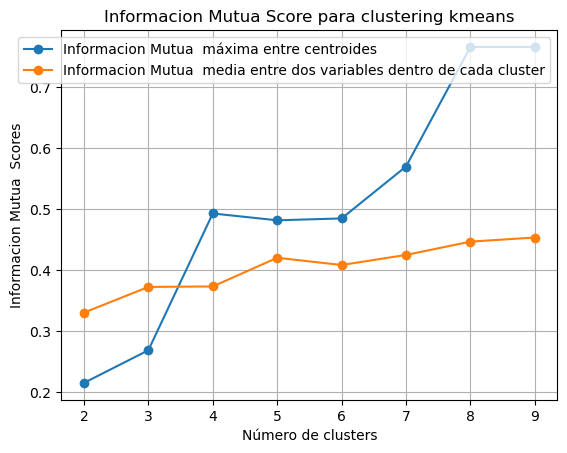

In [ ]:
mi_df = infoCruzadaMatrix (df1)
dist = 1 - mi_df.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed")
X_mds = mds.fit_transform(dist_matrix)

minMI_scores_mean = []
meanMI_scores_mean = []
centroidesMaxMI_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_mds)
    cluster_df = pd.DataFrame({'variable': mi_df.columns, 'cluster': labels})
    closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_mds) #sacar centroide
    variables_cercanas = mi_df.columns[closest]
    df_centroides = df1[variables_cercanas]
    df_centrMI = infoCruzadaMatrix (df_centroides)
    MI_values = abs(df_centrMI.values.copy())
    np.fill_diagonal(MI_values, np.nan)
    max_MI = np.nanmax(MI_values)
    centroidesMaxMI_scores.append(max_MI)
    minMI_scores = []
    meanMI_scores = []
    for cl in range(k):
        vars_cl = cluster_df[cluster_df['cluster'] == cl]['variable'].to_list()
        df_cluster_i = df1[vars_cl]
        df_clMI = infoCruzadaMatrix (df_cluster_i)
        MI_cl = abs(df_clMI)
        minMI = MI_cl.min().min()
        meanMI = MI_cl.mean().mean()
        minMI_scores.append(minMI)
        meanMI_scores.append(meanMI)
    minMI_scores_mean.append(np.mean(minMI_scores))
    meanMI_scores_mean.append(np.mean(meanMI_scores))

#plt.plot(range(2, 10), minMI_scores_mean, marker='o', label = 'Informacion Mutua  mínima entre dos variables dentro de cada cluster')
plt.plot(range(2, 10), centroidesMaxMI_scores, marker='o', label = 'Informacion Mutua  máxima entre centroides')
plt.plot(range(2, 10), meanMI_scores_mean, marker='o', label = 'Informacion Mutua  media entre dos variables dentro de cada cluster')
plt.title('Informacion Mutua Score para clustering kmeans')
plt.xlabel('Número de clusters')
plt.ylabel('Informacion Mutua  Scores')
plt.grid(True)
plt.legend()
plt.show()

Elegimos 3 grupos

In [ ]:
threshold

np.float64(0.3807616686178646)

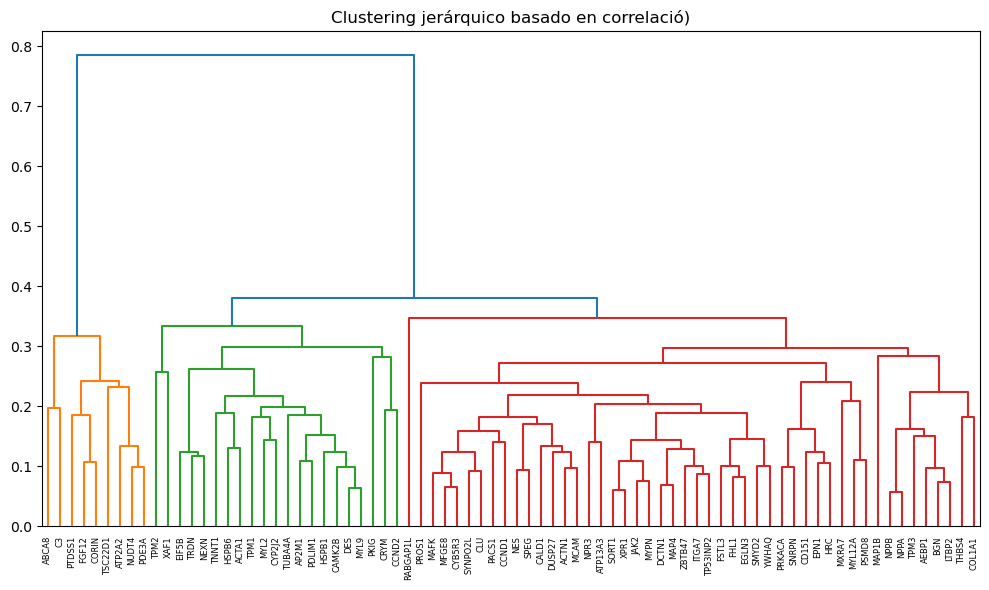

In [18]:
labels_jerar = fcluster(Z, t=3, criterion='maxclust')

threshold = Z[-3 + 1, 2] 
cluster_dfjerar = pd.DataFrame({'variable': corr.columns, 'clusterJerarquico': labels_jerar})
# Dibuja dendrograma con color_threshold
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=corr.columns, leaf_rotation=90, color_threshold=threshold)
plt.title('Clustering jerárquico basado en correlació)')
plt.tight_layout()
plt.show()

In [19]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)
kmeans = KMeans(n_clusters=3, random_state=42)
labelskmeans = kmeans.fit_predict(X_mds)
cluster_df_kmeans = pd.DataFrame({'variable': corr.columns, 'clusterKmeans': labelskmeans})

In [20]:
cluster_df = pd.merge(cluster_dfjerar,cluster_df_kmeans, on = 'variable')

In [21]:
mismatch_clust = []
for i in range(1,4):
    df_cl_mismatch = cluster_df[cluster_df['clusterJerarquico'] == i]
    mismatch = df_cl_mismatch['clusterKmeans'].value_counts(normalize = True).max()
    mismatch_clust.append(mismatch)
np.mean(mismatch_clust)

np.float64(0.9454365079365079)

Visualizar

In [24]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_mds)
cluster_df = pd.DataFrame({'variable': df1.columns, 'clusterKmeans': labels})
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_mds) #sacar centroide
variables_cercanas = df1.columns[closest]
df_centroides = df1[variables_cercanas]

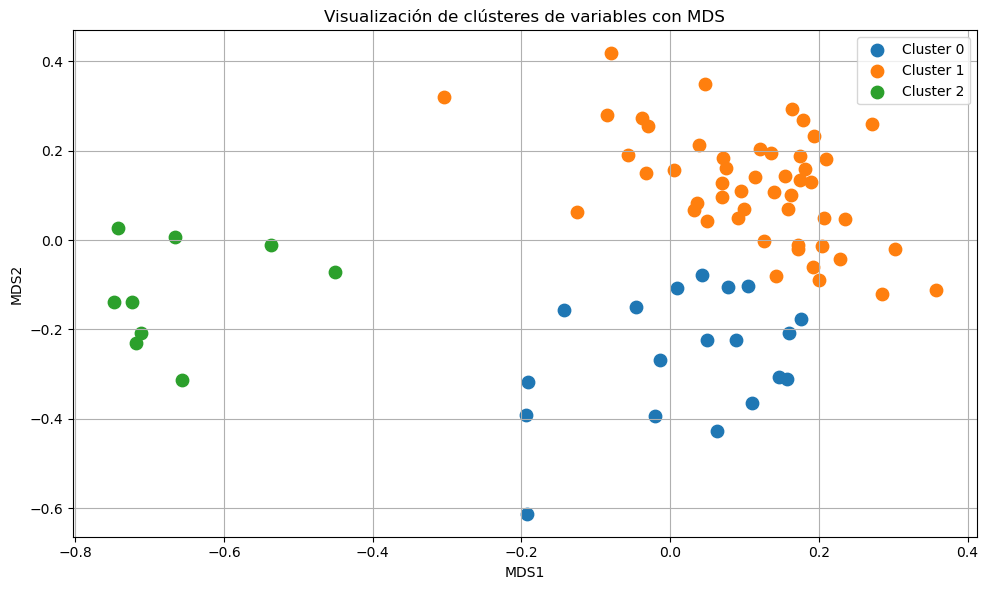

In [25]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)

coords_df = pd.DataFrame({
    'variable': df1.columns,
    'x': X_mds[:, 0],
    'y': X_mds[:, 1],
    'cluster': cluster_df['clusterKmeans']   # los labels que te salieron de KMeans o jerárquico
})

plt.figure(figsize=(10, 6))
for cl in sorted(coords_df['cluster'].unique()):
    sub = coords_df[coords_df['cluster'] == cl]
    plt.scatter(sub['x'], sub['y'], label=f'Cluster {cl}', s=80)

#vars_centroids = coords_df[coords_df['variable'].isin(variables_cercanas)]    
#plt.scatter(vars_centroids['x'], vars_centroids['y'], label=f'Centroides', s=80)
#for _, row in coords_df.iterrows():
 #   plt.text(row['x'], row['y'], row['variable'], fontsize=8, alpha=0.6)

plt.title('Visualización de clústeres de variables con MDS')
plt.xlabel('MDS1')
plt.ylabel('MDS2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
df1_tras = df1.T.reset_index().rename(columns = {'index': 'variable'})
df1_tras_cluster = pd.merge(cluster_df, df1_tras)
df1_cluster0 = df1_tras_cluster[df1_tras_cluster['clusterKmeans'] == 0].set_index('variable').drop(columns = ['clusterKmeans']).T
df1_cluster1 = df1_tras_cluster[df1_tras_cluster['clusterKmeans'] == 1].set_index('variable').drop(columns = ['clusterKmeans']).T
df1_cluster2 = df1_tras_cluster[df1_tras_cluster['clusterKmeans'] == 2].set_index('variable').drop(columns = ['clusterKmeans']).T
df1_clusterList = [df1_cluster0,df1_cluster1,df1_cluster2]

In [44]:
df1_tras_cluster[['variable', 'clusterKmeans']].sort_values('clusterKmeans').rename(columns = {'clusterKmeans' : 'grupo'}).to_csv('vars_cluster.csv',index = False)
df1.to_csv('df_proteines_totalRelevant.csv')

Boxplots intergrupales (si hay un grupo mas característico de cara a la normalización)

estadístico por grupo en base a ver diffs 


interpretacion biologica par cada cluster


mirar que grupo de variables diferencian entre grupo de control y tratamineto 


PCA antes del clustering




### Trabajo con cada cluster

In [ ]:

df1_clusterList_pred = []
for i in df1_clusterList:
    j = i.copy().reset_index()
    j['Grupo'] = np.where(j['index'].str.contains('A'), 'Tratamiento', 
                np.where(j['index'].str.contains('C'), 'Control', 'Otro'))
    j = j.set_index('index')
    j = pd.get_dummies(j, columns=['Grupo'], drop_first=True)
    j['Grupo_Tratamiento'] = j['Grupo_Tratamiento'].astype(int)
    df1_clusterList_pred.append(j)


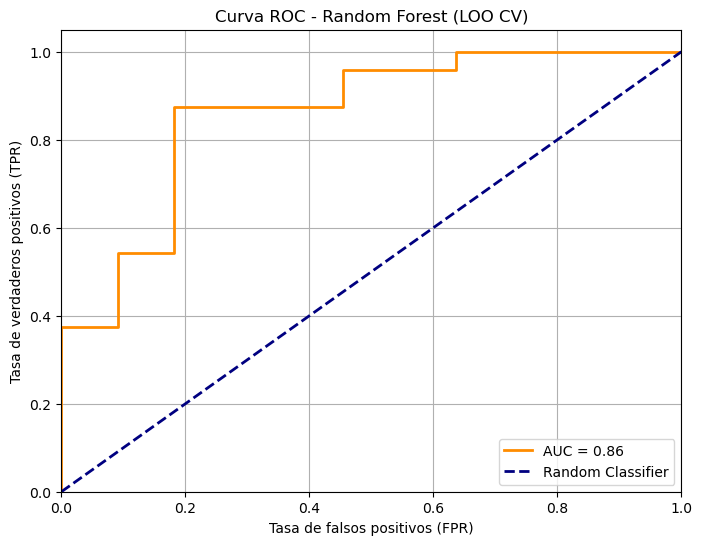

Precisión media en entrenamiento: 1.0
Precisión media en test: 0.8285714285714286
AUC de la curva ROC: 0.8598484848484849
Tasa de verdaderos negativos (TNR - especificidad): 0.7272727272727273
Tasa de falsos negativos (FNR): 0.125
Tasa de verdaderos  positivos (TPR): 0.875
Tasa de falsos positivos (FPR): 0.2727272727272727
HSPB6     0.149086
DES       0.109164
MYL9      0.099584
HSPB1     0.088441
CRYM      0.085351
MYL2      0.078701
ACTA1     0.075933
TNNT1     0.045454
CYP2J2    0.042074
TPM2      0.038334
MYL12A    0.037843
EIF5B     0.033092
XAF1      0.023681
CAMK2B    0.023452
NEXN      0.020780
TPM1      0.014194
PKIG      0.013385
TUBA4A    0.012013
TRDN      0.009438
dtype: float64


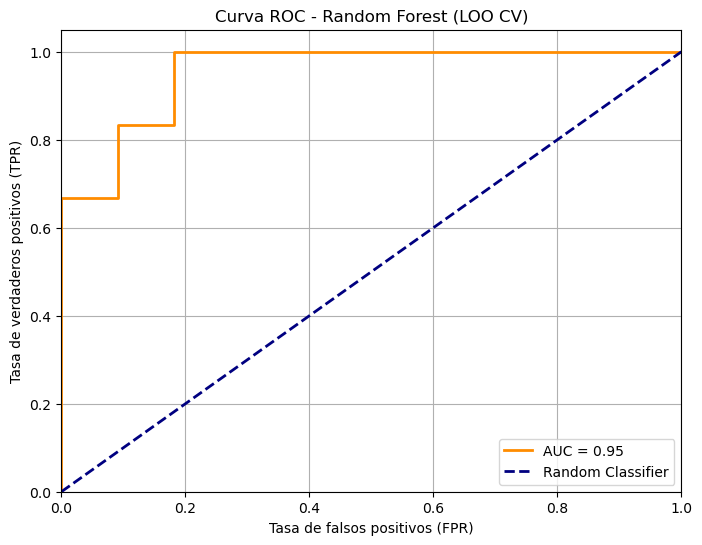

Precisión media en entrenamiento: 1.0
Precisión media en test: 0.8857142857142857
AUC de la curva ROC: 0.9545454545454545
Tasa de verdaderos negativos (TNR - especificidad): 0.8181818181818182
Tasa de falsos negativos (FNR): 0.08333333333333333
Tasa de verdaderos  positivos (TPR): 0.9166666666666666
Tasa de falsos positivos (FPR): 0.18181818181818182
NPPB        0.135812
THBS4       0.126266
NPPA        0.104365
CLU         0.067485
MAP1B       0.063386
FHL1        0.047498
BGN         0.043701
SYNPO2L     0.031538
FSTL3       0.031451
NPR3        0.023864
MFGE8       0.023519
MAFK        0.022210
COL1A1      0.019201
CCND2       0.017727
DUSP27      0.017055
AEBP1       0.013459
PDLIM1      0.013416
ACTN1       0.013370
LTBP2       0.013202
PACS1       0.011483
RABGAP1L    0.010613
PSMD8       0.010543
EGLN3       0.010413
TPM3        0.009106
CYB5R3      0.009050
ZBTB47      0.008329
SMYD2       0.007841
MCAM        0.007479
MXRA7       0.007324
NES         0.006339
PRKACA      0.006

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score,cross_val_predict, train_test_split
from sklearn.metrics  import roc_curve, auc, accuracy_score,confusion_matrix
import matplotlib.pyplot as plt

imp_medias_list = []
for df1_cluster_i in df1_clusterList:
    df2 = df1_cluster_i.copy().reset_index()
    df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
                np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
    df2 = df2.set_index('index')
    df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
    df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

    n_estimators = 300
    max_depth = 3

    X = df2.drop(columns=["Grupo_Tratamiento"])  
    y = df2["Grupo_Tratamiento"]

    # Inicializar LOO
    loo = LeaveOneOut()

    # Acumuladores
    accuracies_train = []
    accuracies_test = []
    y_true = []
    y_pred_proba = []
    y_pred_class = []
    modelos = []
    importancias = []
    # Loop LOO
    for train_index, test_index in loo.split(X):
        rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        
        rf.fit(X_train, y_train)

        # Predicciones
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        y_test_proba = rf.predict_proba(X_test)[:, 1]

        # Guardar resultados
        accuracies_train.append(accuracy_score(y_train, y_train_pred))
        accuracies_test.append(accuracy_score(y_test, y_test_pred))
        y_true.append(y_test.values[0])
        y_pred_proba.append(y_test_proba[0])
        y_pred_class.append(y_test_pred[0])
        importances = rf.feature_importances_
        feature_names = X.columns
        feat_importances = pd.DataFrame(importances, index=feature_names).T
        importancias.append(feat_importances)
        modelos.append(rf)
    importancias = pd.concat(importancias)
    # Calcular AUC y ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Matriz de confusión agregada
    cm = confusion_matrix(y_true, y_pred_class)
    TN, FP, FN, TP = cm.ravel()

    # Métricas adicionales
    TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
    FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
    TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de falsos positivos (FPR)')
    plt.ylabel('Tasa de verdaderos positivos (TPR)')
    plt.title('Curva ROC - Random Forest (LOO CV)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Resultados
    print("Precisión media en entrenamiento:", np.mean(accuracies_train))
    print("Precisión media en test:", np.mean(accuracies_test))
    print("AUC de la curva ROC:", roc_auc)
    print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
    print("Tasa de falsos negativos (FNR):", FNR)
    print("Tasa de verdaderos  positivos (TPR):", TPR)
    print("Tasa de falsos positivos (FPR):", FPR)

    imp_medias = importancias.mean().sort_values(ascending = False)
    print(imp_medias)
    imp_medias_list.append(imp_medias)

### Reducir variables redundantes

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### 1) En base a Componentes principales

In [1176]:
n_components = 1
df1_pca_list = []
for cl in range(3):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df1_clusterList[cl])
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    df_pca = pd.DataFrame(X_pca,columns=[f'Clus{cl}Comp{i}' for i in range(X_pca.shape[1])],index=df1_clusterList[cl].index)
    df1_pca_list.append(df_pca)
df2 = pd.concat(df1_pca_list,axis = 1)
#print(len(df1.columns), 'variables =>', len(df2.columns), 'componentes')

In [ ]:
df2b = df2.copy().reset_index() 
df2b ['Grupo'] = np.where(df2b ['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2b ['index'].str.contains('C'), 'Control', 'Otro'))
df2b = df2b .set_index('index')
df2b = pd.get_dummies(df2b , columns=['Grupo'], drop_first=True)
df2b ['Grupo_Tratamiento'] = df2b ['Grupo_Tratamiento'].astype(int)

In [ ]:
for col in df2b.columns:
    if col != 'Grupo_Tratamiento':
        sns.boxplot(data=df2b, 
                    x='Grupo_Tratamiento', 
                    y=col, 
                    palette='Set2')

        plt.xlabel('Grupo de tratamiento')
        plt.ylabel(f'Magnitud de {col}')
        plt.title(f'Distribución de {col} por grupo')
        plt.grid(True)
        plt.savefig(f"../graphics/boxplot_{col}_proteines.png", bbox_inches='tight', dpi=300)
        plt.show()

#### 2) En base a variables más representativas por cluster

In [30]:
vars_exp = []
for cl in range(3):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df1_clusterList[cl])
    X_scaled = pd.DataFrame(X_scaled, columns=df1_clusterList[cl].columns, index=df1_clusterList[cl].index)
    pca = PCA()
    X_cluster = X_scaled.values 
    pca.fit(X_scaled)

    var_exp = pca.explained_variance_ratio_
    vars_exp.append(var_exp)

In [34]:
df1_clusters = [df1_cluster0,df1_cluster1,df1_cluster2]
loadingsPond = []
vars_sel_list = []
for cl in range(3):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df1_clusters[cl])
    X_scaled = pd.DataFrame(X_scaled, columns=df1_clusters[cl].columns, index=df1_clusters[cl].index)
    pca = PCA()
    X_cluster = X_scaled.values 
    pca.fit(X_scaled)
    #df_loadings = pd.DataFrame(pca.components_[0],index = df1_clusters[cl].columns)
    df_loadings = pd.DataFrame(pca.components_,index=[f'PC{i+1}' for i in range(pca.n_components_)],columns=df1_clusters[cl].columns).T
    var_exp = pca.explained_variance_ratio_
    df_ponderado = df_loadings * var_exp
    media_pond = df_ponderado.T.sum().abs().sort_values(ascending = False)
    loadingsPond.append(media_pond)
    #Seleccionamos aquellas variables de cada cluster cuya contribución ponderada al PCA sea mayor que la media de todas las contribuciones
    vars_select = media_pond[media_pond >= media_pond.mean() + media_pond.std()].index.to_list()
    vars_sel_list.append(vars_select)
vars_select_finales = [item for sublista in vars_sel_list for item in sublista]
df2 = df1[vars_select_finales]
print(len(df1.columns), 'variables =>', len(df2.columns), 'variables')

78 variables => 12 variables


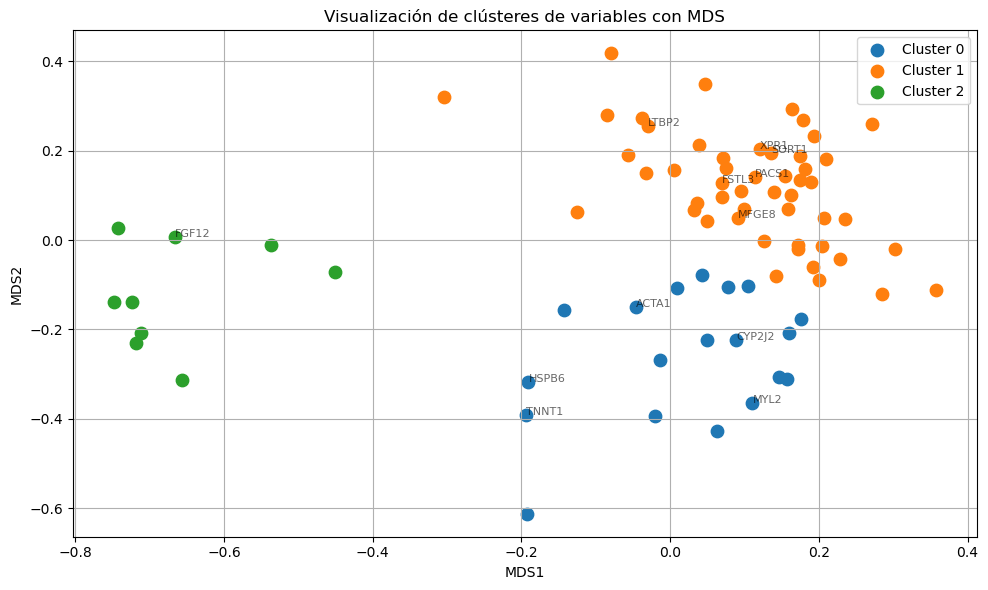

In [35]:
corr = df1.corr()
dist = 1 - corr.abs()
dist_matrix = dist.values
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dist_matrix)

coords_df = pd.DataFrame({
    'variable': df1.columns,
    'x': X_mds[:, 0],
    'y': X_mds[:, 1],
    'cluster': cluster_df['clusterKmeans']   # los labels que te salieron de KMeans o jerárquico
})

plt.figure(figsize=(10, 6))
for cl in sorted(coords_df['cluster'].unique()):
    sub = coords_df[coords_df['cluster'] == cl]
    plt.scatter(sub['x'], sub['y'], label=f'Cluster {cl}', s=80)
    for _, row in coords_df.iterrows():
        if row['variable'] in vars_sel_list[cl]:
            plt.text(row['x'], row['y'], row['variable'], fontsize=8, alpha=0.6)


  
#plt.scatter(vars_centroids['x'], vars_centroids['y'], label=f'Centroides', s=80)

plt.title('Visualización de clústeres de variables con MDS')
plt.xlabel('MDS1')
plt.ylabel('MDS2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

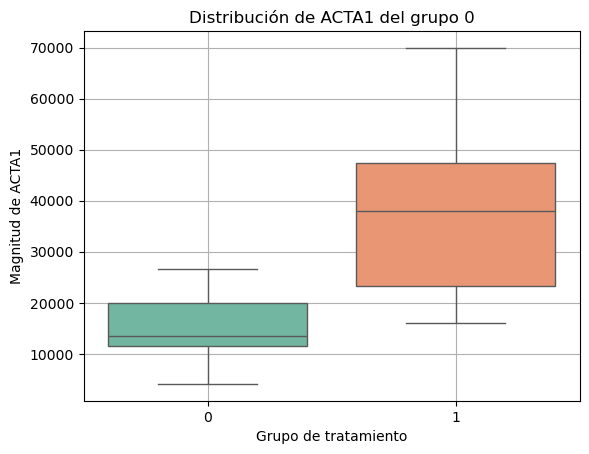

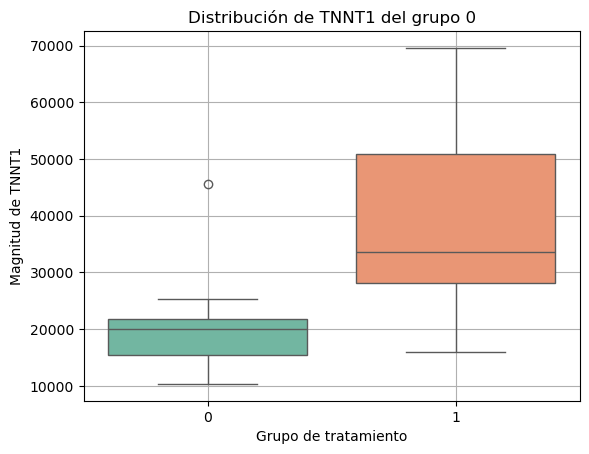

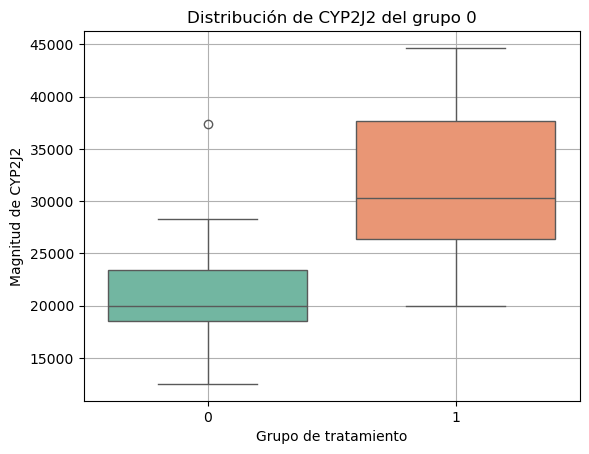

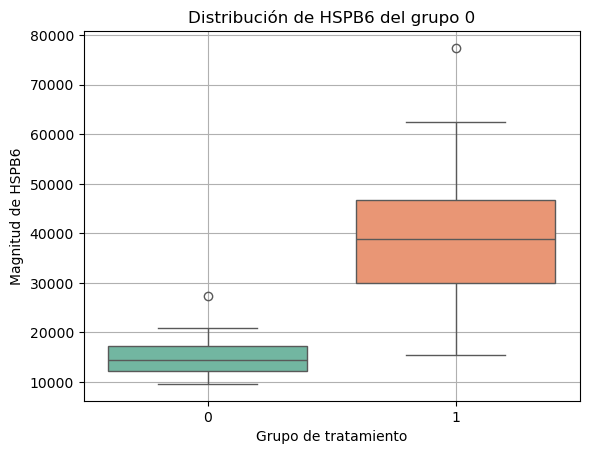

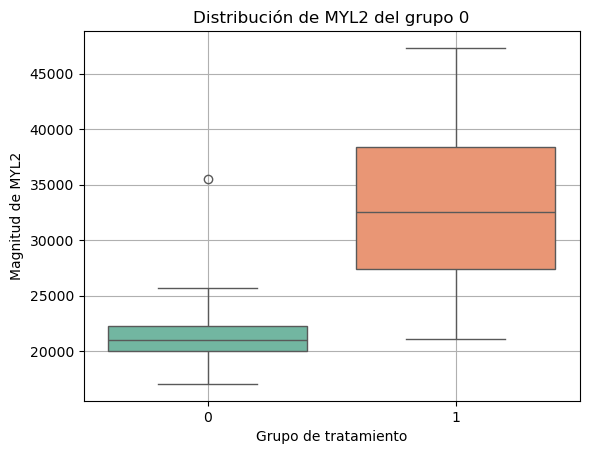

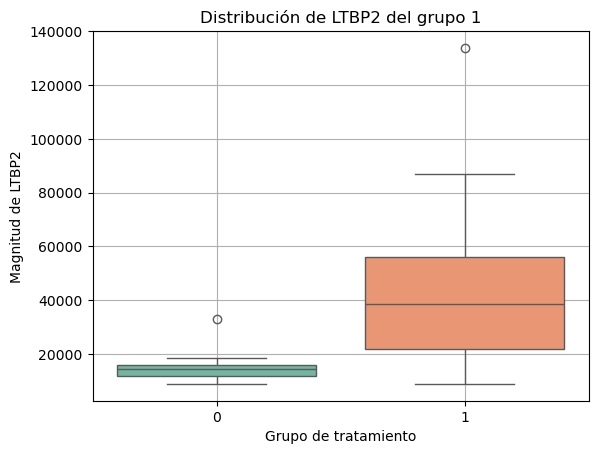

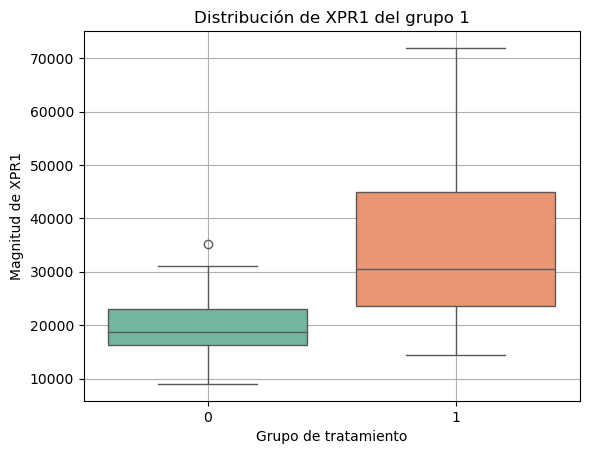

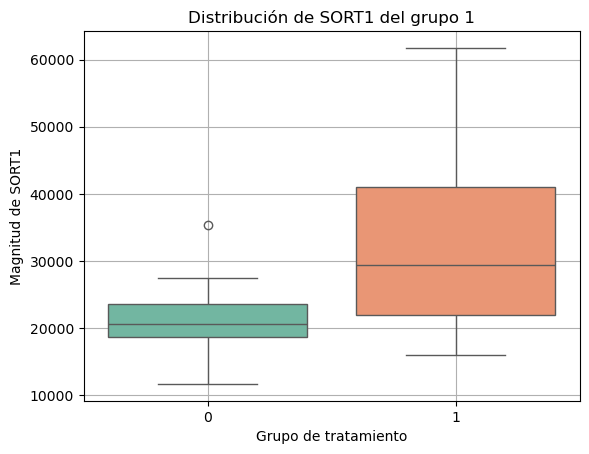

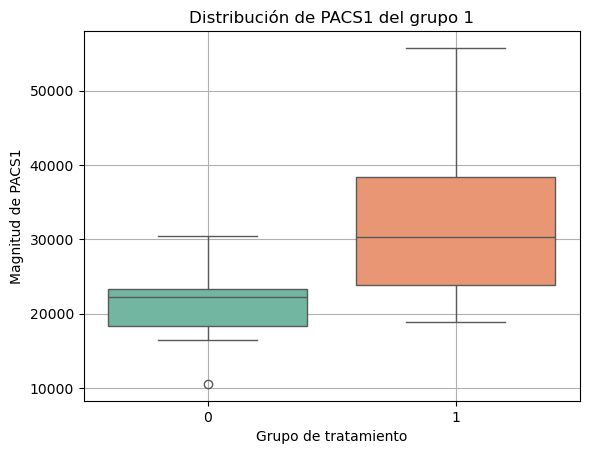

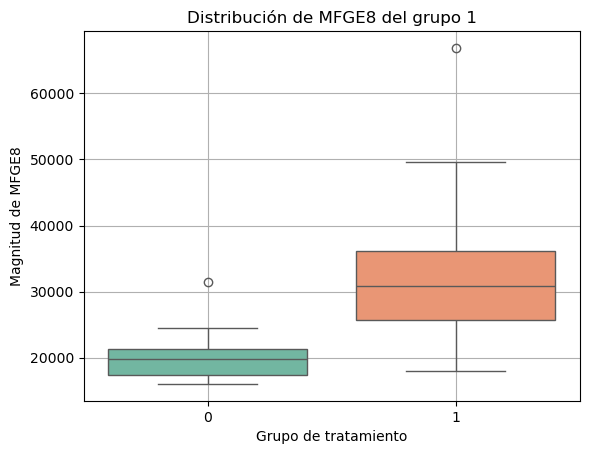

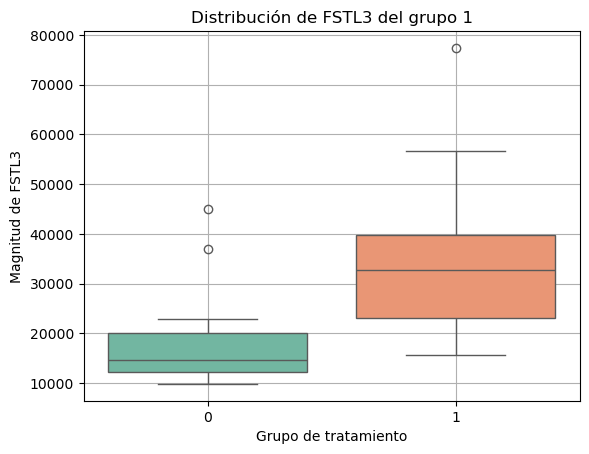

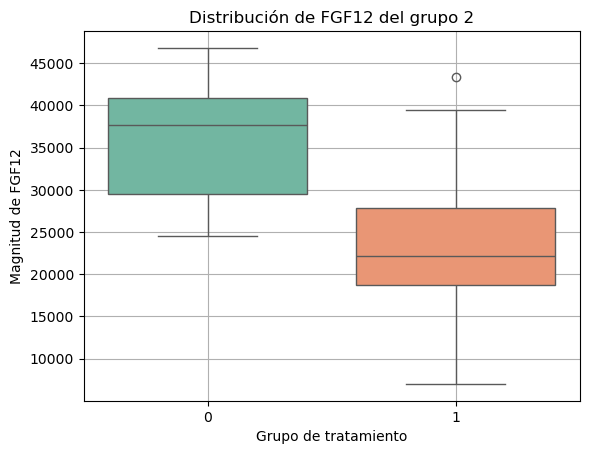

In [1202]:
df3 = df2.copy().reset_index() 
df3 ['Grupo'] = np.where(df3 ['index'].str.contains('A'), 'Tratamiento', 
              np.where(df3 ['index'].str.contains('C'), 'Control', 'Otro'))
df3 = df3 .set_index('index')
df3 = pd.get_dummies(df3 , columns=['Grupo'], drop_first=True)
df3 ['Grupo_Tratamiento'] = df3 ['Grupo_Tratamiento'].astype(int)
for col in df3.columns:
    if col != 'Grupo_Tratamiento':
        cluster = coords_df[coords_df['variable'] == col]['cluster'].to_list()[0]
        sns.boxplot(data=df3, 
                    x='Grupo_Tratamiento', 
                    y=col, 
                    palette='Set2')

        plt.xlabel('Grupo de tratamiento')
        plt.ylabel(f'Magnitud de {col}')
        plt.title(f'Distribución de {col} del grupo {cluster}')
        plt.grid(True)
        plt.savefig(f"../graphics/boxplot_{col}_proteines_ grupo_{cluster}.png", bbox_inches='tight', dpi=300)
        plt.show()

#### boxplots por variable

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
df1b = df1.copy().reset_index() 
df1b ['Grupo'] = np.where(df1b ['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1b ['index'].str.contains('C'), 'Control', 'Otro'))
df1b = df1b .set_index('index')
df1b = pd.get_dummies(df1b , columns=['Grupo'], drop_first=True)
df1b ['Grupo_Tratamiento'] = df1b ['Grupo_Tratamiento'].astype(int)
with PdfPages("boxplots_por_variable.pdf") as pdf:
    for col in df1b.columns:
        if col != 'Grupo_Tratamiento':
            plt.figure(figsize=(8, 6))
            sns.boxplot(data=df1b, 
                        x='Grupo_Tratamiento', 
                        y=col, 
                        palette='Set2')
            
            plt.xlabel('Grupo de tratamiento')
            plt.ylabel(f'Magnitud de {col}')
            plt.title(f'Distribución de {col} por grupo')
            plt.grid(True)
            pdf.savefig()
            plt.close()

In [1168]:
df2.columns

Index(['ACTA1', 'TNNT1', 'CYP2J2', 'HSPB6', 'MYL2', 'LTBP2', 'XPR1', 'SORT1',
       'PACS1', 'MFGE8', 'FSTL3', 'FGF12'],
      dtype='object')

### Correlaciones

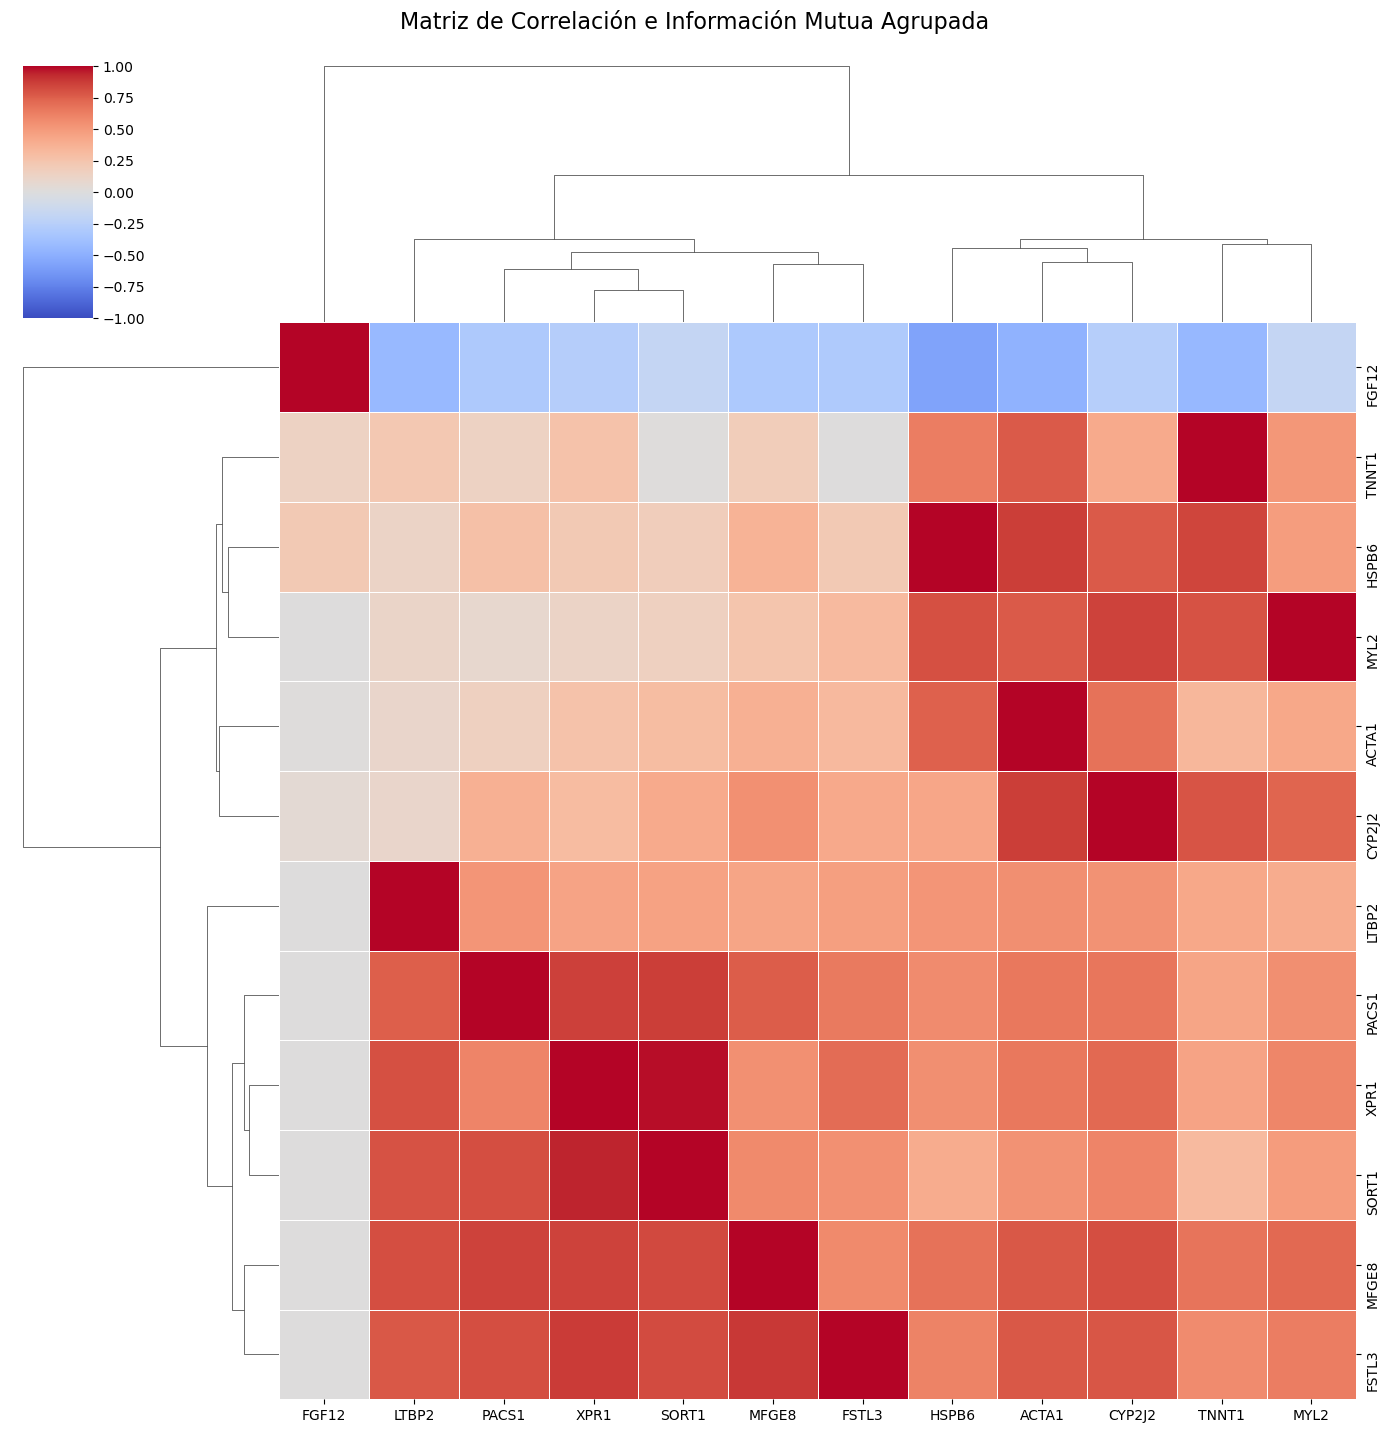

In [ ]:
from sklearn.feature_selection import mutual_info_regression

corr = df2.corr(method='spearman')  
mi_matrix = np.zeros_like(corr) 

for i in range(len(df2.columns)):
    for j in range(i+1, len(df2.columns)):
        mi = mutual_info_regression(df2[[df2.columns[i]]], df2[[df2.columns[j]]])[0]
        mi_matrix[i, j] = mi
        mi_matrix[j, i] = mi
combined_matrix = np.copy(corr)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # Máscara para el lado superior de la diagonal
combined_matrix[mask] = mi_matrix[mask]

cluster = sns.clustermap(combined_matrix,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7},
                         xticklabels=df2.columns,
                         yticklabels=df2.columns) 
cluster.fig.suptitle('Matriz de Correlación e Información Mutua Agrupada', y=1.02, fontsize=16)
cluster.fig.savefig("../graphics/clustermap_correlacion_informacion_mutuaPROTEINAS.png", bbox_inches='tight', dpi=300)

plt.show()

### Perfilados 

In [ ]:
df3 = df2.copy().reset_index()
df3['Grupo'] = np.where(df3['index'].str.contains('A'), 'Tratamiento', 
              np.where(df3['index'].str.contains('C'), 'Control', 'Otro'))
df3 = df3.set_index('index')
df3 = pd.get_dummies(df3, columns=['Grupo'], drop_first=True)
df3['Grupo_Tratamiento'] = df3['Grupo_Tratamiento'].astype(int)

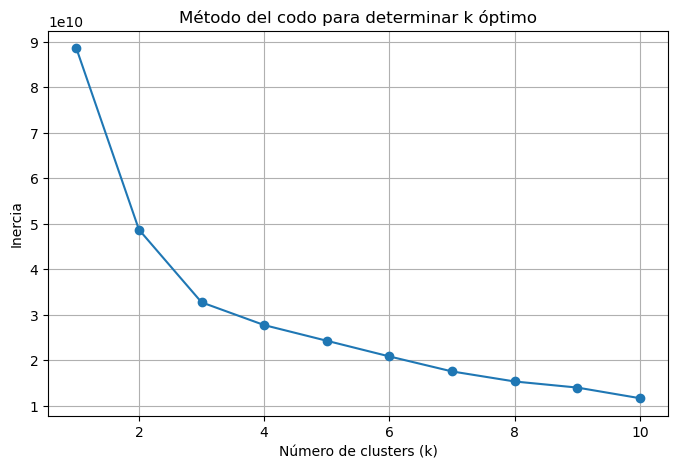

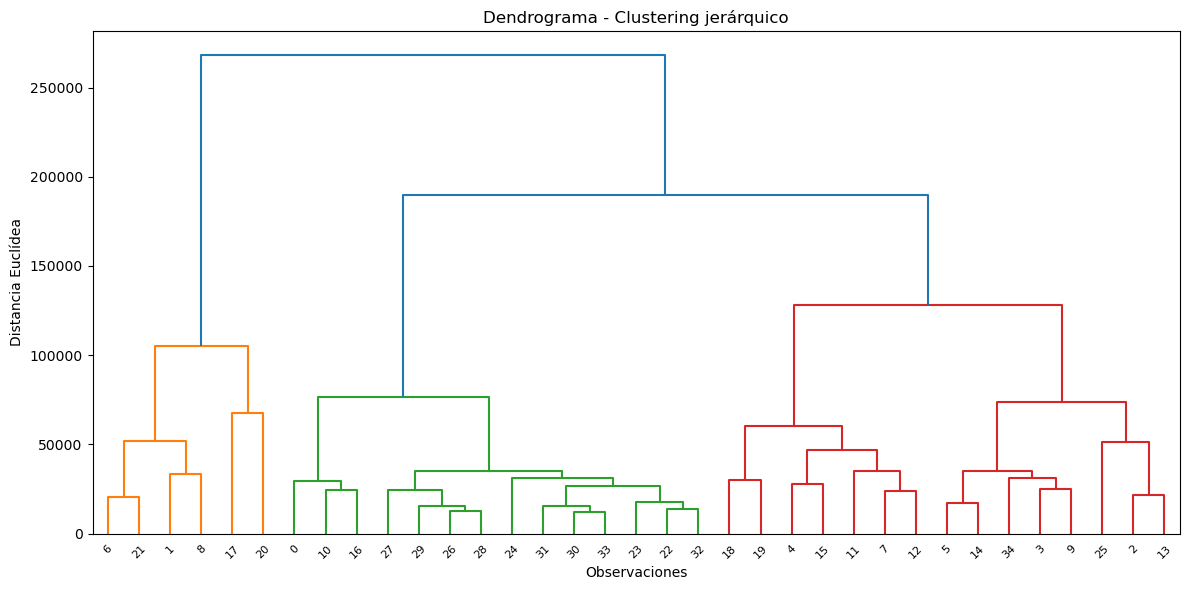

In [ ]:
inertias = []
k_range = range(1, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df2)
    inertias.append(kmeans.inertia_)  # Inercia = suma de distancias cuadradas al centro del clúster


plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para determinar k óptimo')
plt.grid(True)
plt.show()

Z = linkage(df2, method='ward') 

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Dendrograma - Clustering jerárquico')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclídea')
plt.tight_layout()
plt.show()

3 clusters

In [1162]:
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(df2)

df2a = df2.copy().reset_index()
df2a['cluster'] = clusters


df2a['Grupo'] = np.where(df2a['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2a['index'].str.contains('C'), 'Control', 'Otro'))
df2a = df2a.set_index('index')
df2a = pd.get_dummies(df2a, columns=['Grupo'], drop_first=True)
df2a['Grupo_Tratamiento'] = df2a['Grupo_Tratamiento'].astype(int)
#df2a = df2a[['cluster','Grupo_Tratamiento']]

In [1163]:
porcGrupos = {}
for clus in range(3):
    df_cluster = df2a[df2a['cluster'] == clus]
    cantidadTrmento = len(df_cluster[df_cluster['Grupo_Tratamiento'] == 1])#/len(df_cluster)
    cantidadctrl = len(df_cluster[df_cluster['Grupo_Tratamiento'] == 0])#/len(df_cluster)
    porcGrupos.update({clus:{'tratamiento':cantidadTrmento, 'control': cantidadctrl}})
porcGrupos

{0: {'tratamiento': 12, 'control': 1},
 1: {'tratamiento': 6, 'control': 10},
 2: {'tratamiento': 6, 'control': 0}}

### Random Forests

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score,cross_val_predict, train_test_split
from sklearn.metrics  import roc_curve, auc, accuracy_score,confusion_matrix
import matplotlib.pyplot as plt



df3 = df2.copy().reset_index()
df3['Grupo'] = np.where(df3['index'].str.contains('A'), 'Tratamiento', 
              np.where(df3['index'].str.contains('C'), 'Control', 'Otro'))
df3 = df3.set_index('index')
df3 = pd.get_dummies(df3, columns=['Grupo'], drop_first=True)
df3['Grupo_Tratamiento'] = df3['Grupo_Tratamiento'].astype(int)

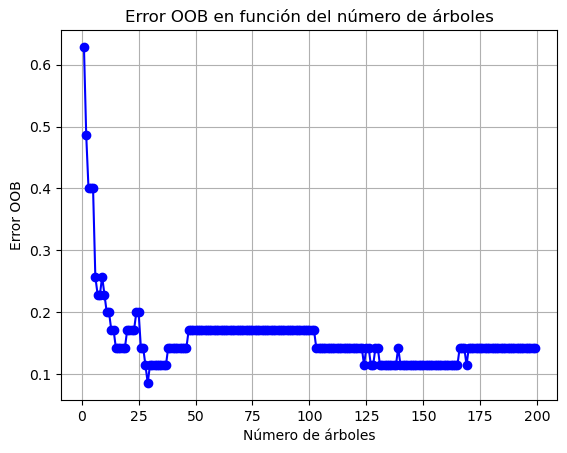

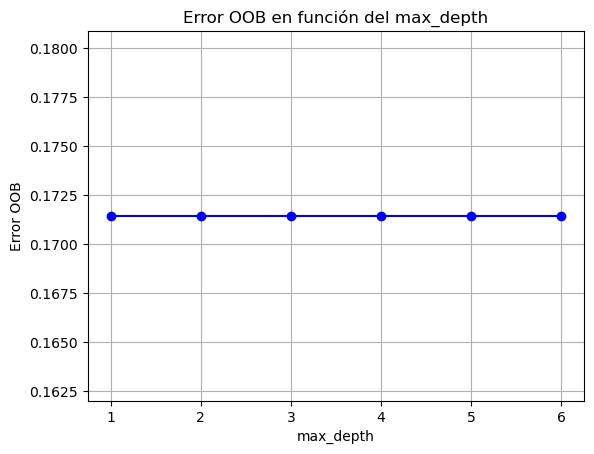

In [ ]:
X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]
estimadores = range(1, 200, 1)
oob_errors = []

for n_estimators in estimadores:  
    rf = RandomForestClassifier(n_estimators=n_estimators, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(estimadores, oob_errors, marker='o', color='b')
plt.xlabel('Número de árboles')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del número de árboles')
plt.grid(True)
plt.show()

oob_errors = []
profundidades = range(1, 7)
for max_depth in profundidades:  
    rf = RandomForestClassifier(n_estimators=300, max_depth=max_depth, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(profundidades, oob_errors, marker='o', color='b')
plt.xlabel('max_depth')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del max_depth')
plt.grid(True)
plt.show()

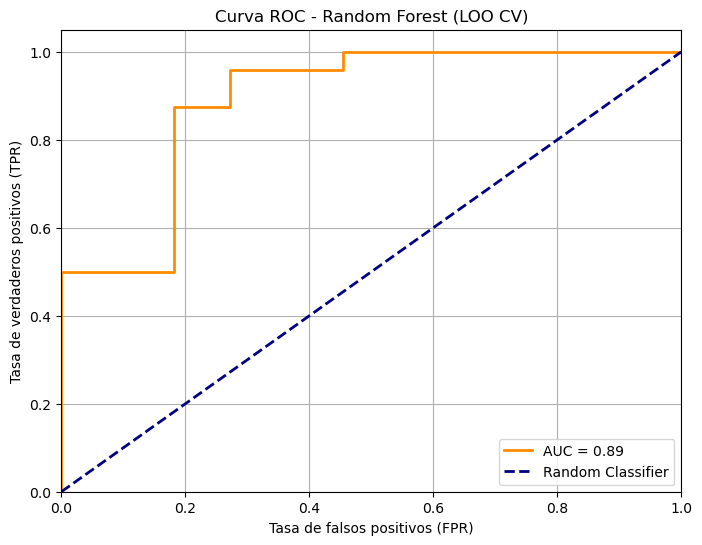

Precisión media en entrenamiento: 1.0
Precisión media en test: 0.8285714285714286
AUC de la curva ROC: 0.8901515151515151
Tasa de verdaderos negativos (TNR - especificidad): 0.7272727272727273
Tasa de falsos negativos (FNR): 0.125
Tasa de verdaderos  positivos (TPR): 0.875
Tasa de falsos positivos (FPR): 0.2727272727272727


In [ ]:
n_estimators = 300
max_depth = 3

X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]

# Inicializar LOO
loo = LeaveOneOut()

# Acumuladores
accuracies_train = []
accuracies_test = []
y_true = []
y_pred_proba = []
y_pred_class = []
modelos = []
importancias = []
# Loop LOO
for train_index, test_index in loo.split(X):
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    
    rf.fit(X_train, y_train)

    # Predicciones
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    # Guardar resultados
    accuracies_train.append(accuracy_score(y_train, y_train_pred))
    accuracies_test.append(accuracy_score(y_test, y_test_pred))
    y_true.append(y_test.values[0])
    y_pred_proba.append(y_test_proba[0])
    y_pred_class.append(y_test_pred[0])
    importances = rf.feature_importances_
    feature_names = X.columns
    feat_importances = pd.DataFrame(importances, index=feature_names).T
    importancias.append(feat_importances)
    modelos.append(rf)
importancias = pd.concat(importancias)
# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_true, y_pred_class)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest (LOO CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
print("Precisión media en entrenamiento:", np.mean(accuracies_train))
print("Precisión media en test:", np.mean(accuracies_test))
print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)

In [ ]:
imp_df = importancias.mean().sort_values(ascending = False).reset_index()
imp_df = imp_df.rename(columns = {'index':'variable', 0 : 'Importancia'})
imp_df = pd.merge(imp_df, cluster_df, how = 'inner',on = 'variable')
imp_df


,variable,Importancia,clusterKmeans
0,HSPB6,0.177365,0
1,MYL2,0.120954,0
2,ACTA1,0.115454,0
3,FGF12,0.096119,2
4,CYP2J2,0.083719,0
5,TNNT1,0.083477,0
6,LTBP2,0.082938,1
7,FSTL3,0.082865,1
8,MFGE8,0.066006,1
9,PACS1,0.043777,1


In [ ]:
imp_df[imp_df['clusterKmeans'] != 1]['Importancia'].sum()

np.float64(0.6770879588042188)

### Interpretaciones

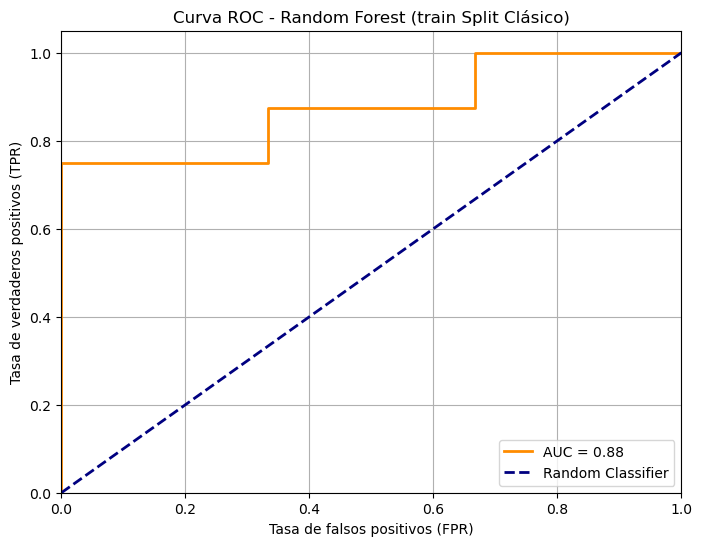

Precisión media en entrenamiento: 1.0
Precisión media en test: 0.8285714285714286
AUC de la curva ROC: 0.875
Tasa de verdaderos negativos (TNR - especificidad): 0.6666666666666666
Tasa de falsos negativos (FNR): 0.25
Tasa de verdaderos  positivos (TPR): 0.75
Tasa de falsos positivos (FPR): 0.3333333333333333


In [ ]:
n_estimators = 50
max_depth = 3

X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # datos
    test_size=0.3,          # 20% para test, 80% para entrenamiento
    stratify=y,
    random_state=42
)
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
y_test_proba = rf.predict_proba(X_test)[:, 1]


importances = rf.feature_importances_
feature_names = X.columns
feat_importances = pd.DataFrame(importances, index=feature_names).T

# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest (train Split Clásico)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
print("Precisión media en entrenamiento:", np.mean(accuracies_train))
print("Precisión media en test:", np.mean(accuracies_test))
print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)

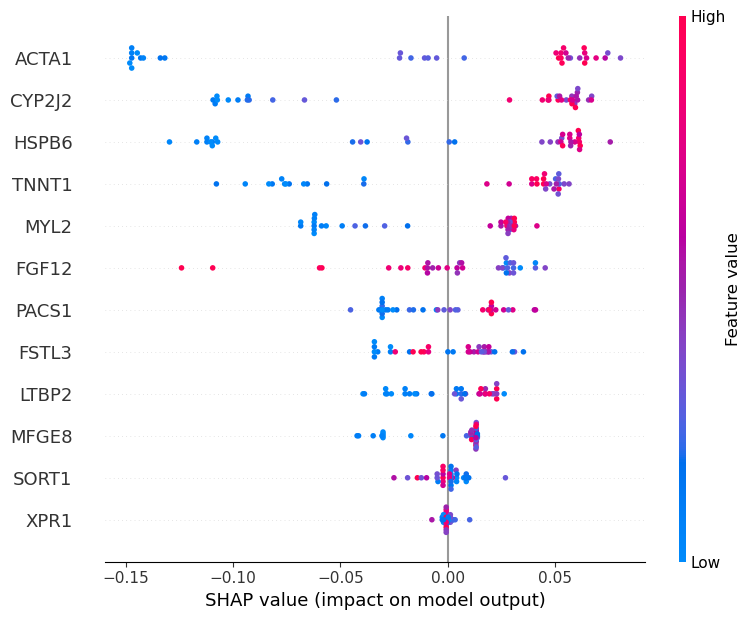

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Gráfico resumen
shap.summary_plot(shap_values[:, :, 1], X)

### Logística

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [ ]:
def discretizar_variables(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)

    return data_encoded

df4 = discretizar_variables(df2, 3)
df4 = pd.concat([df4,df3['Grupo_Tratamiento']], axis = 1)

Exactitud: 1.00
AUC: 1.00


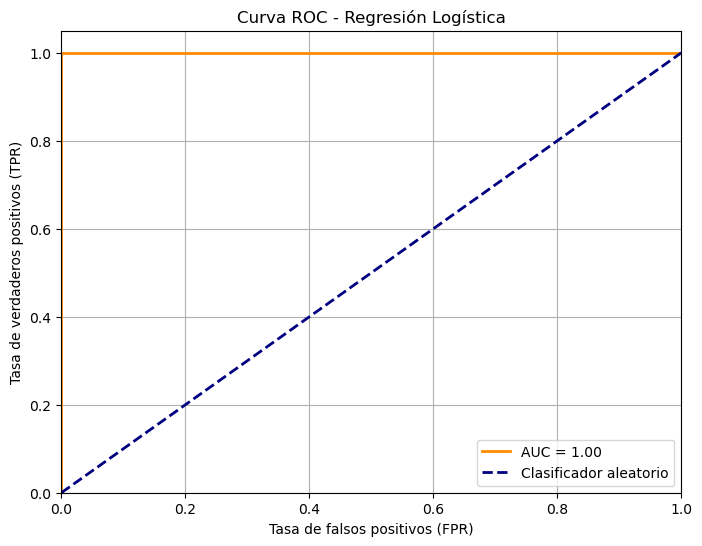

Coeficientes del modelo:


,Característica,Coeficiente
2,ACTA1_2,0.168139
9,HSPB6_0,-1.240255
11,HSPB6_2,0.182435
17,LTBP2_2,0.032283
19,XPR1_1,0.753820
26,PACS1_2,1.214465
31,FSTL3_1,0.780908
33,FGF12_0,0.997608


In [ ]:
X = df4.drop(columns=["Grupo_Tratamiento"])  
y = df4["Grupo_Tratamiento"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(penalty='l1', solver='liblinear')

# Entrenar el modelo
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1] 

accuracy = accuracy_score(y_test, y_pred)
print(f'Exactitud: {accuracy:.2f}')



fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
print(f'AUC: {roc_auc:.2f}')

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


coefficients = pd.DataFrame({
    'Característica': X.columns,
    'Coeficiente': log_reg.coef_[0]
})
print("Coeficientes del modelo:")
coefficients[coefficients['Coeficiente'] != 0]

In [ ]:
(coefficients)

,Característica,Coeficiente
0,ACTA1_0,0.000000
1,ACTA1_1,0.000000
2,ACTA1_2,0.168139
3,TNNT1_0,0.000000
4,TNNT1_1,0.000000
5,TNNT1_2,0.000000
6,CYP2J2_0,0.000000
7,CYP2J2_1,0.000000
8,CYP2J2_2,0.000000
9,HSPB6_0,-1.240255
